# OP3 compound-clustered BCa (Chem-style)

Paired deltas vs **none**, with uncertainty over the **35 held-out test molecules**,
using the Chem-PerturBridge **baseline-adjustment agreement** bootstrap recipe.

**Metrics (same definitions as `op3_signatures/src/metrics/`):**
- **MRRMSE** = `mean_rowwise_rmse` (lower better)
- **MAE** = `mean_rowwise_mae` (lower better)
- **Spearman** = `mean_rowwise_spearman` (higher better)
- **Cosine** = `mean_rowwise_cosine` (higher better)

**Design:**
1. Seed-average row scores once (outside bootstrap).
2. Precompute row-level paired Δ and row-level win indicators.
3. Compound-clustered nested mean over `cell_type` strata.
4. 95% BCa via Chem `cluster_bca_nested_mean_ci_table` (2000 draws, seed `20260505`; jackknife over compounds).

**Delta sign:** positive = variant better than `none`
(`ref − var` for error; `var − ref` for correlation).

**Win rate (aligned with Δ):** unit-level `win_row = 1` if variant is better on that
compound×cell_type (seed-averaged scores). Same nested mean / BCa as Δ
(equal-weight over cell types within compound, then over compounds).

**Win rate (compound, no bootstrap):** seed-average scores, average within each
compound over cell types, compare to reference → `win_compound`; mean over compounds
→ `win_rate_compound` (point estimate only).

Point estimates follow the Chem nested mean (equal-weight over cell-type strata).


In [40]:
from __future__ import annotations

import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from scipy.stats import rankdata

CHEM_SCRIPTS = Path("/home/icb/olga.novitskaia/Chem-PerturBridge_analysis/scripts")
sys.path.insert(0, str(CHEM_SCRIPTS))
from cluster_bootstrap_ci import (  # noqa: E402
    OBSERVED_COMPOUND_PANEL_SCOPE,
    cluster_bca_nested_mean_ci_table,
)

OP3_ROOT = Path("/home/icb/olga.novitskaia/op3_signatures/data/benchmark")
DE_TEST = OP3_ROOT / "resources/datasets/neurips-2023-data-subsample/de_test.h5ad"
PRED_ROOT = OP3_ROOT / "results/methods"
MET_ROOT = OP3_ROOT / "results/metrics/methods"
METHOD_PREFIX = "nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_"

REF_METHOD = "none"
VAR_METHODS = [
    "lpm_trainable_all_20",
    "fp_trainable_fp",
    "lpm_trainable_l1000_20",
    "fp_fixed_fp",
    "chemb1_fixed_chemb1",
    "chemb1_trainable_chemb1",
    "chemb2_fixed_chemb2",
    "chemb2_trainable_chemb2",
    "molformer_fixed_molformer",
    "molformer_trainable_molformer",
    "lpm_trainable_all_20_narrowed",
]
ALL_METHODS = [REF_METHOD] + VAR_METHODS

SEEDS = [0, 1, 2, 3, 4, 10, 11, 12, 13, 14]
N_BOOT = 2000
BOOTSTRAP_SEED = 20260505
CI_LEVEL = 0.95
DE_TEST_LAYER = "clipped_sign_log10_pval"
PRED_LAYER = "prediction"

OUTPUT_DIR = Path("/home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_SPECS = {
    "mrrmse": {
        "metric_name": "delta_mean_rowwise_mrrmse",
        "op3_name": "mean_rowwise_rmse",
        "higher_is_better": False,
    },
    "mae": {
        "metric_name": "delta_mean_rowwise_mae",
        "op3_name": "mean_rowwise_mae",
        "higher_is_better": False,
    },
    "spearman": {
        "metric_name": "delta_mean_rowwise_spearman",
        "op3_name": "mean_rowwise_spearman",
        "higher_is_better": True,
    },
    "cosine": {
        "metric_name": "delta_mean_rowwise_cosine",
        "op3_name": "mean_rowwise_cosine",
        "higher_is_better": True,
    },
}


In [41]:
def _decode(x):
    if isinstance(x, bytes):
        return x.decode()
    if isinstance(x, np.ndarray):
        return np.array([_decode(v) for v in x], dtype=object)
    return x


def read_categorical(f: h5py.File, key: str) -> np.ndarray:
    cats = _decode(f[f"obs/{key}/categories"][:].astype(object))
    codes = f[f"obs/{key}/codes"][:]
    return np.asarray(cats)[codes]


def load_de_test(path: Path = DE_TEST):
    with h5py.File(path, "r") as f:
        Y = f[f"layers/{DE_TEST_LAYER}"][:].astype(np.float64)
        genes = _decode(f["var/_index"][:].astype(object))
        compound = read_categorical(f, "SMILES")
        cell_type = read_categorical(f, "cell_type")
    return Y, genes, compound.astype(str), cell_type.astype(str)


def load_prediction(path: Path, gene_order: np.ndarray) -> np.ndarray:
    with h5py.File(path, "r") as f:
        X = f[f"layers/{PRED_LAYER}"][:].astype(np.float64)
        genes = _decode(f["var/_index"][:].astype(object))
    if not np.array_equal(genes, gene_order):
        pos = {g: i for i, g in enumerate(genes)}
        X = X[:, [pos[g] for g in gene_order]]
    if np.isnan(X).any():
        X = np.nan_to_num(X, nan=0.0)
    return X


def pred_path(method: str, seed: int) -> Path:
    return PRED_ROOT / f"{METHOD_PREFIX}{method}" / "stability" / f"predictions_seed_{seed}.h5ad"


def metric_path(method: str, seed: int, kind: str) -> Path:
    return MET_ROOT / f"{METHOD_PREFIX}{method}" / "stability" / f"seed_{seed}" / f"{kind}.h5ad"


def read_stored_metrics(method: str, seed: int) -> dict[str, float]:
    out = {}
    for kind in ("mean_rowwise_error", "mean_rowwise_correlation"):
        with h5py.File(metric_path(method, seed, kind), "r") as f:
            ids = [_decode(x) for x in f["uns/metric_ids"][:]]
            vals = f["uns/metric_values"][:]
            out.update({i: float(v) for i, v in zip(ids, vals)})
    return out


def row_mrrmse(y: np.ndarray, p: np.ndarray) -> np.ndarray:
    return np.sqrt(np.mean((y - p) ** 2, axis=1))


def row_mae(y: np.ndarray, p: np.ndarray) -> np.ndarray:
    return np.mean(np.abs(y - p), axis=1)


def row_spearman(y: np.ndarray, p: np.ndarray) -> np.ndarray:
    yr = np.apply_along_axis(rankdata, 1, y).astype(np.float64)
    pr = np.apply_along_axis(rankdata, 1, p).astype(np.float64)
    yr -= yr.mean(axis=1, keepdims=True)
    pr -= pr.mean(axis=1, keepdims=True)
    num = (yr * pr).sum(axis=1)
    den = np.sqrt((yr * yr).sum(axis=1) * (pr * pr).sum(axis=1))
    out = np.zeros(y.shape[0], dtype=np.float64)
    ok = den > 0
    out[ok] = num[ok] / den[ok]
    out[~np.isfinite(out)] = 0.0
    return out


def row_cosine(y: np.ndarray, p: np.ndarray) -> np.ndarray:
    num = (y * p).sum(axis=1)
    den = np.linalg.norm(y, axis=1) * np.linalg.norm(p, axis=1)
    out = np.zeros(y.shape[0], dtype=np.float64)
    ok = den > 0
    out[ok] = num[ok] / den[ok]
    out[~np.isfinite(out)] = 0.0
    return out


ROW_SCORE_FNS = {
    "mrrmse": row_mrrmse,
    "mae": row_mae,
    "spearman": row_spearman,
    "cosine": row_cosine,
}


In [42]:
Y, genes, compounds, cell_types = load_de_test()
unique_compounds = np.array(sorted(pd.unique(compounds)))
n_compounds = len(unique_compounds)
compound_to_rows = {c: np.flatnonzero(compounds == c) for c in unique_compounds}

print(f"de_test: {Y.shape[0]} rows x {Y.shape[1]} genes")
print(f"n_compounds={n_compounds}  cell_types={sorted(pd.unique(cell_types))}")
print(f"reference={REF_METHOD}  n_variants={len(VAR_METHODS)}  metrics={list(METRIC_SPECS)}")


de_test: 138 rows x 5317 genes
n_compounds=35  cell_types=['B cells', 'Myeloid cells', 'NK cells', 'T cells']
reference=none  n_variants=11  metrics=['mrrmse', 'mae', 'spearman', 'cosine']


## Load scores + sanity check vs stored OP3 metrics


In [43]:
try:
    display
except NameError:
    def display(x):
        print(x)


def load_method_row_scores(method: str) -> dict[str, np.ndarray]:
    out = {k: np.empty((len(SEEDS), Y.shape[0]), dtype=np.float64) for k in ROW_SCORE_FNS}
    for i, seed in enumerate(SEEDS):
        pred = load_prediction(pred_path(method, seed), genes)
        for score, fn in ROW_SCORE_FNS.items():
            out[score][i] = fn(Y, pred)
    return out


check_rows = []
all_scores = {}
for method in ALL_METHODS:
    print(f"Loading + checking {method}")
    scores = load_method_row_scores(method)
    all_scores[method] = scores
    for i, seed in enumerate(SEEDS):
        stored = read_stored_metrics(method, seed)
        for score in ROW_SCORE_FNS:
            op3_name = METRIC_SPECS[score]["op3_name"]
            recomputed = float(scores[score][i].mean())
            stored_v = stored[op3_name]
            check_rows.append(
                {
                    "method": method,
                    "seed": seed,
                    "score": score,
                    "op3_name": op3_name,
                    "recomputed": recomputed,
                    "stored": stored_v,
                    "abs_diff": abs(recomputed - stored_v),
                }
            )

check_df = pd.DataFrame(check_rows)
check_path = OUTPUT_DIR / "op3_metric_recompute_check.tsv"
check_df.to_csv(check_path, sep="\t", index=False)
print(check_df.groupby("score")["abs_diff"].agg(["count", "max", "mean"]).to_string())
print(f"all match (<1e-8): {(check_df['abs_diff'] < 1e-8).all()}")
print(f"Saved {check_path}")

ref_scores = all_scores[REF_METHOD]
variant_scores = {m: all_scores[m] for m in VAR_METHODS}
print(f"Ready: reference + {len(variant_scores)} variants")


Loading + checking none
Loading + checking lpm_trainable_all_20
Loading + checking fp_trainable_fp
Loading + checking lpm_trainable_l1000_20
Loading + checking fp_fixed_fp
Loading + checking chemb1_fixed_chemb1
Loading + checking chemb1_trainable_chemb1
Loading + checking chemb2_fixed_chemb2
Loading + checking chemb2_trainable_chemb2
Loading + checking molformer_fixed_molformer
Loading + checking molformer_trainable_molformer
Loading + checking lpm_trainable_all_20_narrowed
          count           max          mean
score                                      
cosine      120  4.985512e-12  2.453809e-12
mae         120  4.999301e-11  2.505255e-11
mrrmse      120  4.993306e-11  2.456339e-11
spearman    120  4.952316e-12  2.584514e-12
all match (<1e-8): True
Saved /home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style/op3_metric_recompute_check.tsv
Ready: reference + 11 variants


## Chem-style analysis

1. Seed-average row scores once.
2. Precompute row-level paired Δ (`delta_row`) and row-level wins (`win_row`).
3. Compound-clustered nested BCa over `cell_type` for both Δ and win rate.
4. `win_rate_compound`: average seed-avg scores within compound, compare to reference, fraction of compounds won (no bootstrap).


In [44]:
def paired_delta(ref_v: np.ndarray, var_v: np.ndarray, *, higher_is_better: bool) -> np.ndarray:
    return (var_v - ref_v) if higher_is_better else (ref_v - var_v)


def better_mask(ref_v, var_v, *, higher_is_better: bool) -> np.ndarray:
    return (var_v > ref_v) if higher_is_better else (var_v < ref_v)


# Seed-average once (outside bootstrap).
ref_row_avg = {score: ref_scores[score].mean(axis=0) for score in METRIC_SPECS}
var_row_avg = {
    method: {score: scores[score].mean(axis=0) for score in METRIC_SPECS}
    for method, scores in variant_scores.items()
}

# Long frame of precomputed unit-level Δ and wins (one row per condition × method × metric).
delta_records = []
for method in VAR_METHODS:
    for score, spec in METRIC_SPECS.items():
        hib = spec["higher_is_better"]
        d_row = paired_delta(ref_row_avg[score], var_row_avg[method][score], higher_is_better=hib)
        w_row = better_mask(
            ref_row_avg[score], var_row_avg[method][score], higher_is_better=hib
        ).astype(float)
        for i in range(Y.shape[0]):
            delta_records.append(
                {
                    "var_method": method,
                    "score": score,
                    "op3_name": spec["op3_name"],
                    "metric": spec["metric_name"],
                    "compound": compounds[i],
                    "cell_type": cell_types[i],
                    "delta_row": float(d_row[i]),
                    "win_row": float(w_row[i]),
                }
            )

delta_frame = pd.DataFrame(delta_records)

# Compound view (no bootstrap): average seed-avg scores within compound over
# cell types, then Δ and hard win vs reference. Also used for strip plots.
compound_records = []
for method in VAR_METHODS:
    for score, spec in METRIC_SPECS.items():
        hib = spec["higher_is_better"]
        tmp = pd.DataFrame(
            {
                "compound": compounds,
                "ref": ref_row_avg[score],
                "var": var_row_avg[method][score],
            }
        )
        g = tmp.groupby("compound", as_index=False)[["ref", "var"]].mean()
        d = paired_delta(g["ref"].to_numpy(), g["var"].to_numpy(), higher_is_better=hib)
        for compound, delta_c in zip(g["compound"].to_numpy(), d):
            compound_records.append(
                {
                    "var_method": method,
                    "score": score,
                    "op3_name": spec["op3_name"],
                    "metric": spec["metric_name"],
                    "compound": compound,
                    "delta_compound": float(delta_c),
                    "win_compound": float(delta_c > 0),
                }
            )

win_frame = pd.DataFrame(compound_records)
win_rate_compound = (
    win_frame.groupby(["var_method", "score", "op3_name"], as_index=False)
    .agg(win_rate_compound=("win_compound", "mean"), n_compounds=("compound", "nunique"))
)

print(delta_frame.shape, "unit-level Δ/win rows")
print(win_frame.shape, "compound rows")
display(delta_frame.head(3))
display(win_frame.head(3))
display(win_rate_compound.head(3))


(6072, 8) unit-level Δ/win rows
(1540, 7) compound rows


,var_method,score,op3_name,metric,compound,cell_type,delta_row,win_row
0,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2...,B cells,-0.020494,0.0
1,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2...,Myeloid cells,0.111240,1.0
2,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2...,NK cells,-0.005331,0.0


,var_method,score,op3_name,metric,compound,delta_compound,win_compound
0,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,C/C(=C\c1csc(C)n1)[C@@H]1C[C@@H]2O[C@]2(C)CCC[...,-0.029191,0.0
1,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,C1CCC(C(CC2CCCCN2)C2CCCCC2)CC1,-0.024122,0.0
2,lpm_trainable_all_20,mrrmse,mean_rowwise_rmse,delta_mean_rowwise_mrrmse,C=C1/C(=C\C=C2/CCC[C@]3(C)[C@@H]([C@H](C)CC[C@...,-0.007351,0.0


,var_method,score,op3_name,win_rate_compound,n_compounds
0,chemb1_fixed_chemb1,cosine,mean_rowwise_cosine,0.342857,35
1,chemb1_fixed_chemb1,mae,mean_rowwise_mae,0.171429,35
2,chemb1_fixed_chemb1,mrrmse,mean_rowwise_rmse,0.228571,35


In [46]:
# Chem helper writes its own `metric` label from metric_cols keys, so keep
# OP3 metric name out of group_cols and restore it after.
group_cols = ["var_method", "score", "op3_name"]

# Nested BCa on precomputed Δ_row: cluster=compound, inner=cell_type.
delta_ci = cluster_bca_nested_mean_ci_table(
    delta_frame,
    group_cols=group_cols,
    metric_cols={"delta_row": "delta_row"},
    cluster_col="compound",
    inner_cols=["cell_type"],
    outer_cols=None,
    n_boot=N_BOOT,
    ci_level=CI_LEVEL,
    seed=BOOTSTRAP_SEED,
    summary_level="op3_variant_metric",
    uncertainty_scope=OBSERVED_COMPOUND_PANEL_SCOPE,
)

# Win-rate BCa: same nesting as Δ (unit wins, cluster=compound, inner=cell_type).
win_ci = cluster_bca_nested_mean_ci_table(
    delta_frame,
    group_cols=group_cols,
    metric_cols={"win_rate": "win_row"},
    cluster_col="compound",
    inner_cols=["cell_type"],
    outer_cols=None,
    n_boot=N_BOOT,
    ci_level=CI_LEVEL,
    seed=BOOTSTRAP_SEED,
    summary_level="op3_variant_metric_winrate_nested_celltype",
    uncertainty_scope=OBSERVED_COMPOUND_PANEL_SCOPE,
)

delta_ci = delta_ci.rename(
    columns={
        "mean": "delta_hat",
        "ci_low": "delta_ci_low",
        "ci_high": "delta_ci_high",
        "ci_half_width": "delta_ci_half_width",
        "ci_method": "delta_ci_method",
        "ci_status": "delta_ci_status",
        "n_bootstrap_valid": "delta_n_bootstrap_valid",
        "n_compounds": "n_compounds",
        "metric": "bca_metric_label",
    }
)
win_ci = win_ci.rename(
    columns={
        "mean": "win_rate",
        "ci_low": "win_rate_ci_low",
        "ci_high": "win_rate_ci_high",
        "ci_half_width": "win_rate_ci_half_width",
        "ci_method": "win_rate_ci_method",
        "ci_status": "win_rate_ci_status",
        "n_bootstrap_valid": "win_rate_n_bootstrap_valid",
        "metric": "bca_metric_label",
    }
)

delta_ci["metric"] = delta_ci["score"].map(lambda s: METRIC_SPECS[s]["metric_name"])
win_ci["metric"] = win_ci["score"].map(lambda s: METRIC_SPECS[s]["metric_name"])

merge_keys = ["var_method", "score", "op3_name"]
summary = delta_ci[merge_keys + [
    "metric",
    "delta_hat", "delta_ci_low", "delta_ci_high", "delta_ci_half_width",
    "delta_ci_method", "delta_ci_status", "delta_n_bootstrap_valid",
    "n_compounds", "n_rows", "n_finite_rows", "inner_strata", "cluster_col",
    "ci_level", "n_bootstrap_iterations", "uncertainty_scope",
]].merge(
    win_ci[merge_keys + [
        "win_rate", "win_rate_ci_low", "win_rate_ci_high", "win_rate_ci_half_width",
        "win_rate_ci_method", "win_rate_ci_status", "win_rate_n_bootstrap_valid",
    ]],
    on=merge_keys,
    how="left",
)

summary = summary.merge(
    win_rate_compound[["var_method", "score", "op3_name", "win_rate_compound"]],
    on=["var_method", "score", "op3_name"],
    how="left",
)

summary["ref_method"] = REF_METHOD
summary["excludes_zero"] = summary.apply(
    lambda r: bool(r["delta_ci_low"] > 0 or r["delta_ci_high"] < 0)
    if np.isfinite(r["delta_ci_low"]) else False,
    axis=1,
)
summary["win_rate_excludes_0.5"] = summary.apply(
    lambda r: bool(r["win_rate_ci_low"] > 0.5 or r["win_rate_ci_high"] < 0.5)
    if np.isfinite(r["win_rate_ci_low"]) else False,
    axis=1,
)
summary["n_seeds"] = len(SEEDS)
summary["bootstrap_seed"] = BOOTSTRAP_SEED
summary["design"] = "chem_style_unit_delta_and_win_nested_celltype_seedavg_first"

summary = summary.sort_values(["score", "delta_hat"], ascending=[True, False]).reset_index(drop=True)

summary_path = OUTPUT_DIR / f"op3_cluster_bca_chem_style_nested_win_vs_{REF_METHOD}.tsv"
unit_path = OUTPUT_DIR / f"op3_unit_deltas_chem_style_nested_win_vs_{REF_METHOD}.tsv"
compound_path = OUTPUT_DIR / f"op3_compound_wins_chem_style_nested_win_vs_{REF_METHOD}.tsv"

summary.to_csv(summary_path, sep="\t", index=False)
delta_frame.to_csv(unit_path, sep="\t", index=False)
win_frame.to_csv(compound_path, sep="\t", index=False)

show_cols = [
    "score", "var_method", "delta_hat", "delta_ci_low", "delta_ci_high", "excludes_zero",
    "win_rate", "win_rate_ci_low", "win_rate_ci_high", "win_rate_excludes_0.5",
    "win_rate_compound",
    "delta_ci_method", "inner_strata",
]
display(
    summary[show_cols].style.format(
        {
            "delta_hat": "{:+.6f}",
            "delta_ci_low": "{:.6f}",
            "delta_ci_high": "{:.6f}",
            "win_rate": "{:.3f}",
            "win_rate_ci_low": "{:.3f}",
            "win_rate_ci_high": "{:.3f}",
            "win_rate_compound": "{:.3f}",
        }
    )
)
print(f"\nSaved {summary_path}")
print(f"Saved {unit_path}")
print(f"Saved {compound_path}")
print("win_rate = nested mean of unit wins + BCa (same nesting as delta_hat)")
print("win_rate_compound = no-bootstrap fraction of compounds with cell-type-averaged Δ > 0")
print("compound file: delta_compound / win_compound (seed-avg scores, mean over cell types)")


,score,var_method,delta_hat,delta_ci_low,delta_ci_high,excludes_zero,win_rate,win_rate_ci_low,win_rate_ci_high,win_rate_excludes_0.5,win_rate_compound,delta_ci_method,inner_strata
0,cosine,lpm_trainable_all_20,+0.013787,-0.005411,0.036011,False,0.550,0.414,0.679,False,0.571,bca,cell_type
1,cosine,lpm_trainable_l1000_20,+0.005917,-0.016544,0.027813,False,0.564,0.425,0.688,False,0.600,bca,cell_type
2,cosine,fp_trainable_fp,+0.005190,-0.008177,0.025500,False,0.564,0.442,0.680,False,0.514,bca,cell_type
3,cosine,lpm_trainable_all_20_narrowed,+0.002090,-0.017602,0.022836,False,0.543,0.421,0.671,False,0.457,bca,cell_type
4,cosine,chemb1_trainable_chemb1,+0.000728,-0.020160,0.020709,False,0.558,0.450,0.664,False,0.600,bca,cell_type
5,cosine,molformer_trainable_molformer,-0.012262,-0.048777,0.024722,False,0.507,0.393,0.630,False,0.571,bca,cell_type
6,cosine,chemb2_trainable_chemb2,-0.024933,-0.064355,0.018561,False,0.435,0.318,0.551,False,0.486,bca,cell_type
7,cosine,molformer_fixed_molformer,-0.038446,-0.095620,0.010689,False,0.370,0.254,0.486,True,0.400,bca,cell_type
8,cosine,chemb2_fixed_chemb2,-0.045293,-0.095800,0.009408,False,0.370,0.266,0.491,True,0.314,bca,cell_type
9,cosine,fp_fixed_fp,-0.048298,-0.106208,0.001698,False,0.449,0.322,0.584,False,0.429,bca,cell_type



Saved /home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style/op3_cluster_bca_chem_style_nested_win_vs_none.tsv
Saved /home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style/op3_unit_deltas_chem_style_nested_win_vs_none.tsv
Saved /home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style/op3_compound_wins_chem_style_nested_win_vs_none.tsv
win_rate = nested mean of unit wins + BCa (same nesting as delta_hat)
win_rate_compound = no-bootstrap fraction of compounds with cell-type-averaged Δ > 0
compound file: delta_compound / win_compound (seed-avg scores, mean over cell types)


Saved /home/icb/olga.novitskaia/lpm_style/results/op3_bootstrap_chem_style/op3_compound_delta_strip_nested_win_vs_none.png


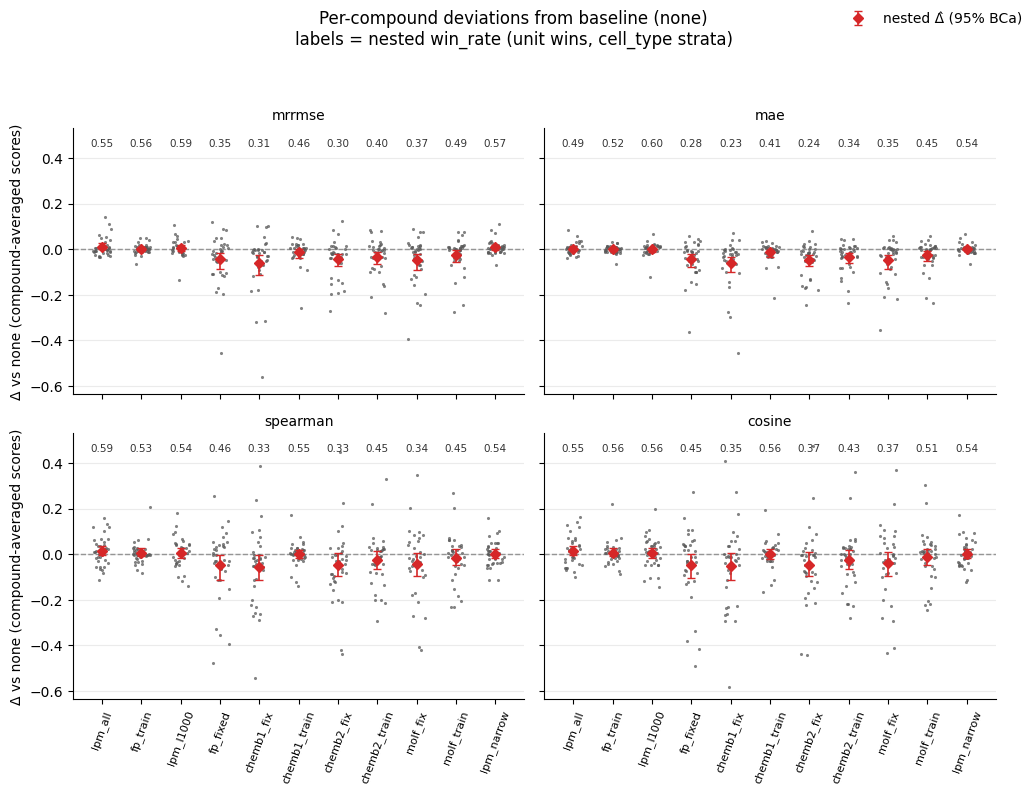

In [47]:
# Compound-level Δ vs none: one point per held-out molecule, by method.
# Points = mean unit Δ over cell types; labels = nested win_rate from summary.
import matplotlib.pyplot as plt
import seaborn as sns

score_order = list(METRIC_SPECS)
method_order = list(VAR_METHODS)
short_labels = {
    "lpm_trainable_all_20": "lpm_all",
    "fp_trainable_fp": "fp_train",
    "lpm_trainable_l1000_20": "lpm_l1000",
    "fp_fixed_fp": "fp_fixed",
    "chemb1_fixed_chemb1": "chemb1_fix",
    "chemb1_trainable_chemb1": "chemb1_train",
    "chemb2_fixed_chemb2": "chemb2_fix",
    "chemb2_trainable_chemb2": "chemb2_train",
    "molformer_fixed_molformer": "molf_fix",
    "molformer_trainable_molformer": "molf_train",
    "lpm_trainable_all_20_narrowed": "lpm_narrow",
}

plot_df = win_frame.copy()
plot_df["method_short"] = plot_df["var_method"].map(short_labels)
method_short_order = [short_labels[m] for m in method_order]

g = sns.catplot(
    data=plot_df,
    x="method_short",
    y="delta_compound",
    col="score",
    col_order=score_order,
    col_wrap=2,
    kind="strip",
    order=method_short_order,
    height=3.8,
    aspect=1.35,
    color="0.35",
    alpha=0.75,
    jitter=0.22,
    s=5,
)
g.set_axis_labels("", "Δ vs none (compound-averaged scores)")
g.set_titles("{col_name}")

# Overlay nested BCa point estimate ± CI from summary (same sign convention).
sum_idx = summary.set_index(["score", "var_method"])

for ax, score in zip(g.axes.flat, score_order):
    ax.axhline(0.0, color="0.55", lw=1.0, ls="--", zorder=0)
    xs = np.arange(len(method_order), dtype=float)
    ys = np.array([float(sum_idx.loc[(score, m), "delta_hat"]) for m in method_order])
    lo = np.array([float(sum_idx.loc[(score, m), "delta_ci_low"]) for m in method_order])
    hi = np.array([float(sum_idx.loc[(score, m), "delta_ci_high"]) for m in method_order])
    yerr = np.vstack([ys - lo, hi - ys])
    ax.errorbar(
        xs,
        ys,
        yerr=yerr,
        fmt="D",
        ms=5,
        color="C3",
        ecolor="C3",
        elinewidth=1.2,
        capsize=3,
        zorder=3,
        label="nested Δ̂ (95% BCa)",
    )
    pad = 0.08 * (np.nanmax(hi) - np.nanmin(lo) + 1e-12)
    ax.set_ylim(min(ax.get_ylim()[0], np.nanmin(lo) - pad), max(ax.get_ylim()[1], np.nanmax(hi) + pad))
    ymin, ymax = ax.get_ylim()
    y_ann = ymax - 0.04 * (ymax - ymin)
    for i, m in enumerate(method_order):
        wr = float(sum_idx.loc[(score, m), "win_rate"])
        ax.text(
            i,
            y_ann,
            f"{wr:.2f}",
            ha="center",
            va="top",
            fontsize=7.5,
            color="0.2",
            clip_on=False,
        )
    ax.tick_params(axis="x", rotation=70, labelsize=8)
    ax.grid(axis="y", alpha=0.25)

handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles, labels, loc="upper right", frameon=False)
g.figure.suptitle(
    f"Per-compound deviations from baseline ({REF_METHOD})\n"
    "labels = nested win_rate (unit wins, cell_type strata)",
    y=1.04,
    fontsize=12,
)
g.tight_layout()

fig_path = OUTPUT_DIR / f"op3_compound_delta_strip_nested_win_vs_{REF_METHOD}.png"
g.figure.savefig(fig_path, dpi=160, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()
